# Stray Light Analysis

**Stray light** is any light that reaches the detector via an unintended path.
In imaging systems the most common form is **ghost images** — weak secondary
images caused by multiple internal reflections from lens surfaces.

The NSQ engine is ideal for stray light analysis because rays propagate freely
between any surfaces and every Fresnel reflection is tracked probabilistically.

This notebook demonstrates:
1. Converting a sequential design to an NSQ scene with `sequential_to_nonsequential`
2. Using `max_depth` to reveal ghost contributions
3. Comparing single-pass vs. multi-bounce irradiance
4. Suppressing ghosts with AR coatings, and using importance-biased sampling to
   measure the resulting faint ghost without a huge ray budget

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import warnings

from optiland.coatings import SimpleCoating
from optiland.coordinate_system import CoordinateSystem
from optiland.nonsequential import (
    NSQScene, Spectrum,
    CollimatedSourceConfig,
    IrradianceDetectorConfig,
    LensConfig, SurfaceConfig,
    sequential_to_nonsequential,
)
from optiland.nonsequential.ir.scene_ir import SamplingPolicy

## 1. Why Sequential-to-NSQ Conversion?

The sequential tracer assumes all light is transmitted at every surface —
there are no reflected beams. The NSQ tracer applies **Fresnel splitting** at
every uncoated interface: each ray is probabilistically refracted *or* reflected
based on the Fresnel equations.

`sequential_to_nonsequential` converts an `Optic` sequential design into an
`NSQScene` automatically:
- Singlet surfaces → `Lens` components
- Cemented doublets → `Doublet` components  
- Mirror surfaces → `Mirror` components
- Image surface → `IrradianceDetector`
- Each sequential field → one NSQ source

In [2]:
from optiland.samples.objectives import CookeTriplet

triplet = CookeTriplet()

# Suppress the expected Fresnel-reflection warning from the converter
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    scene_triplet = sequential_to_nonsequential(
        triplet,
        detector_pixels=(256, 256),
    )

print("Compound components:", scene_triplet.component_names)
print("Sources            :", scene_triplet.source_names)
print("Detectors          :", scene_triplet.detector_names)
print(f"Total surfaces     : {len(scene_triplet.surfaces)}")

Compound components: ['L1', 'L3', 'L5']
Sources            : ['S0', 'S1', 'S2']
Detectors          : ['D1']
Total surfaces     : 12


## 2. Baseline Trace

`max_depth` counts **every** interaction a ray has, including the one with the
detector. So the smallest value that lets light through a system is

```
max_depth >= (number of refracting surfaces on the direct path) + 1
```

A Cooke Triplet has 6 refracting surfaces, so `max_depth=7` is the minimum for
a direct image and anything above that starts adding ghost paths. We use a
generous limit here so the baseline includes the full Fresnel behaviour.

Note the converter creates one source per sequential field, so `total_flux_in`
is the sum over all fields rather than 1 W.


Baseline flux on detector: 1.70100 W
Rays on detector         : 56,750


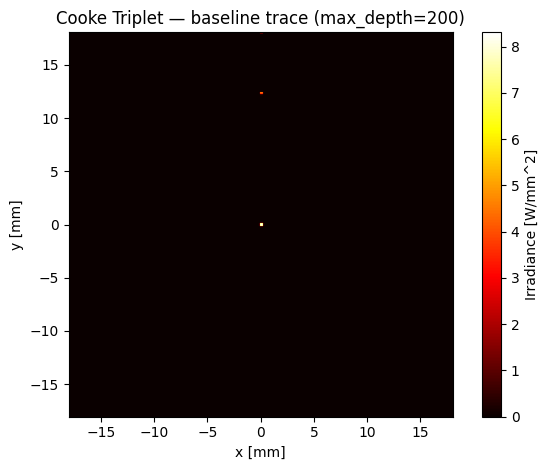

In [3]:
result_base = scene_triplet.trace(num_rays=100_000, max_depth=200, seed=42)
irr_base = result_base.detectors['D1']

print(f"Baseline flux on detector: {irr_base.total_flux:.5f} W")
print(f"Rays on detector         : {irr_base.num_rays_hit:,}")

fig = irr_base.plot(cmap='hot')
plt.title('Cooke Triplet — baseline trace (max_depth=200)')
plt.tight_layout()
plt.show()
plt.close(fig)

## 3. Limited-Bounce Comparison

Lowering `max_depth` restricts how many surface interactions each ray can
have. Rays exceeding the limit are killed without reaching the detector.
Here we compare a tight limit (few ghost paths possible) against the full trace:

Multi-bounce flux on detector : 1.69661 W
Rays on detector              : 113,206


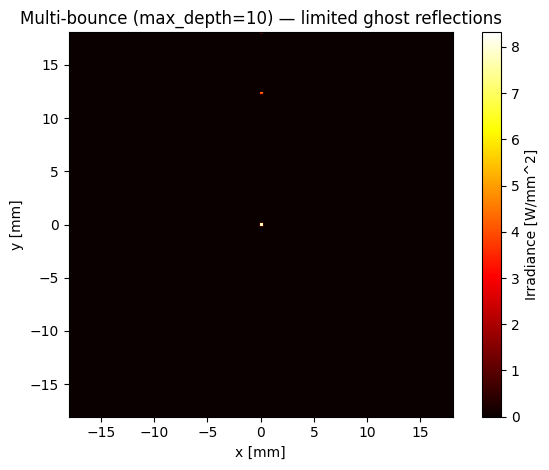

In [4]:
# Rebuild scene each trace (detectors accumulate across calls)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    scene_ghosts = sequential_to_nonsequential(
        CookeTriplet(),
        detector_pixels=(256, 256),
    )

result_ghosts = scene_ghosts.trace(
    num_rays=200_000,
    max_depth=10,
    min_flux_fraction=1e-8,  # track very faint rays
    seed=42,
)
irr_ghosts = result_ghosts.detectors['D1']

print(f"Multi-bounce flux on detector : {irr_ghosts.total_flux:.5f} W")
print(f"Rays on detector              : {irr_ghosts.num_rays_hit:,}")

fig = irr_ghosts.plot(cmap='hot')
plt.title('Multi-bounce (max_depth=10) — limited ghost reflections')
plt.tight_layout()
plt.show()
plt.close(fig)

## 4. Ghost Contribution as a Function of Bounces

Track how the detected flux changes as we allow more reflections:

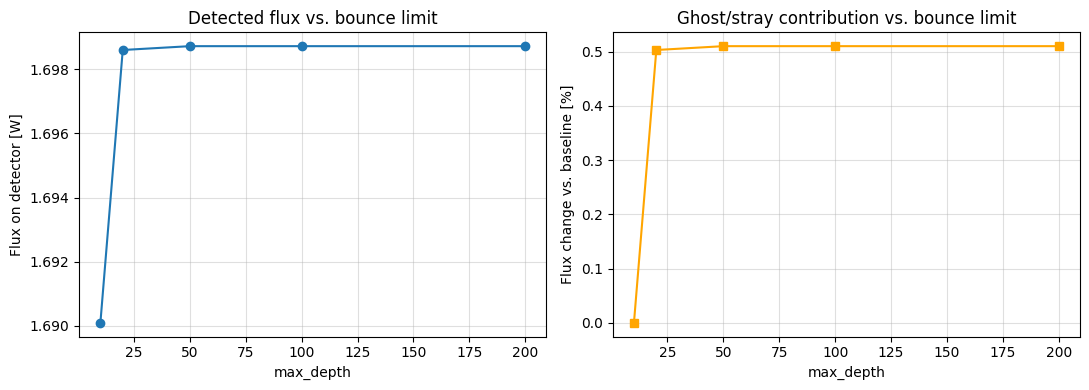

max_depth= 10: flux=1.69010 W  delta=+0.000%
max_depth= 20: flux=1.69860 W  delta=+0.503%
max_depth= 50: flux=1.69872 W  delta=+0.510%
max_depth=100: flux=1.69872 W  delta=+0.510%
max_depth=200: flux=1.69872 W  delta=+0.510%


In [5]:
bounce_levels = [10, 20, 50, 100, 200]
detected_fluxes = []

for max_b in bounce_levels:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        sc = sequential_to_nonsequential(CookeTriplet(), detector_pixels=(128, 128))
    r = sc.trace(num_rays=50_000, max_depth=max_b, min_flux_fraction=1e-8, seed=42)
    detected_fluxes.append(r.detectors['D1'].total_flux)

# Compute ghost fraction relative to lowest-bounce baseline (guard against zero)
base = detected_fluxes[0] if detected_fluxes[0] > 1e-12 else max(detected_fluxes)
ghost_fractions = [
    (f - base) / base * 100
    for f in detected_fluxes
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(bounce_levels, detected_fluxes, 'o-')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Flux on detector [W]')
axes[0].set_title('Detected flux vs. bounce limit')
axes[0].grid(True, alpha=0.4)

axes[1].plot(bounce_levels, ghost_fractions, 's-', color='orange')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('Flux change vs. baseline [%]')
axes[1].set_title('Ghost/stray contribution vs. bounce limit')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()
plt.close(fig)

for b, f, g in zip(bounce_levels, detected_fluxes, ghost_fractions):
    print(f"max_depth={b:>3}: flux={f:.5f} W  delta={g:+.3f}%")

## 5. Isolating the Ghost Contribution

Building a scene by hand gives full control over the bounce budget, and
comparing two bounce limits separates the direct image from the stray light:

- `max_depth = surfaces + 1` allows **only** the direct path.
- A larger limit additionally admits rays that reflected an even number of
  times inside the system, which is exactly what forms a ghost.

Subtracting the two irradiance maps leaves the ghost pattern on its own.

Every surface below is left **uncoated** on purpose, so this is bare-Fresnel
physics: ~4% reflectance at each glass-air interface. That is close to a
worst case — most real imaging lenses carry an AR coating specifically to
suppress this — and section 6 quantifies just how much difference that
coating makes on this exact system.


Direct path only (max_depth=5) : 0.80252 W (160,914 rays)
All paths (max_depth=16)       : 0.80974 W (162,368 rays)
Ghost contribution             : 0.00722 W (0.89% of the detected light)


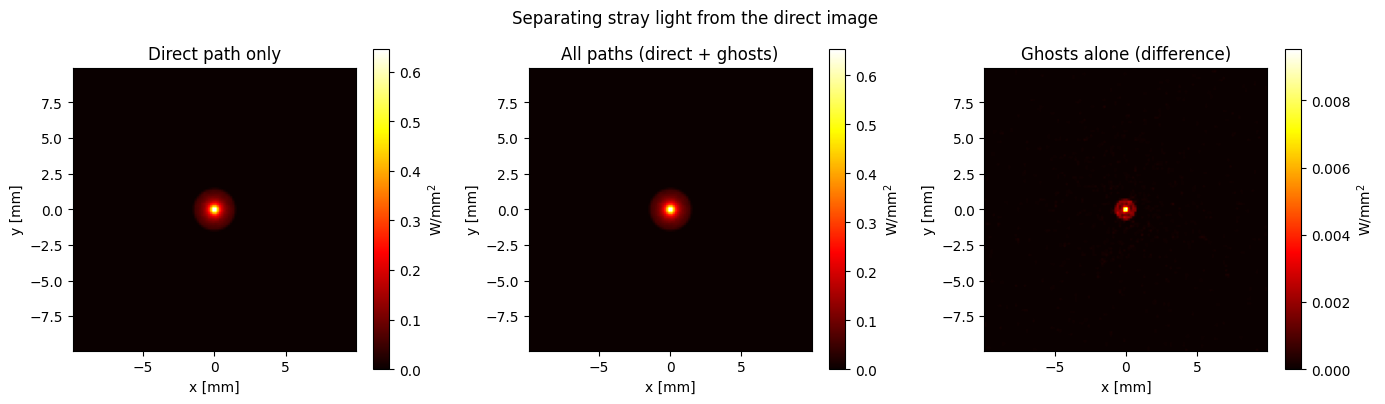

In [6]:
spec = Spectrum.monochromatic(0.55)


def build_stray_scene():
    """Two-element system: 4 refracting surfaces on the direct path."""
    sc = NSQScene()
    sc.add_source(
        'S', CoordinateSystem(z=-80),
        CollimatedSourceConfig(spectrum=spec, total_flux=1.0, aperture_radius=10.0),
    )
    sc.add_lens(
        'L1', CoordinateSystem(z=0),
        LensConfig(r1=50, r2=-50, thickness=5, material='N-BK7',
                   front_aperture_radius=12.5),
    )
    sc.add_lens(
        'L2', CoordinateSystem(z=40),
        LensConfig(r1=-80, r2=80, thickness=4, material='N-SF5',
                   front_aperture_radius=12.5),
    )
    # The biconvex/biconcave pair focuses at z = 60 mm. Stray light is judged
    # against the signal, so the detector belongs where the signal is: at the
    # image, where the wanted light is concentrated and any ghost is not.
    sc.add_detector(
        'D', CoordinateSystem(z=60),
        IrradianceDetectorConfig(width=20, height=20,
                                 num_pixels_x=128, num_pixels_y=128),
    )
    return sc


# 4 refracting surfaces + 1 detector hit = 5 interactions for the direct path.
r_direct = build_stray_scene().trace(
    num_rays=200_000, max_depth=5, min_flux_fraction=1e-8, seed=42)
r_full = build_stray_scene().trace(
    num_rays=200_000, max_depth=16, min_flux_fraction=1e-8, seed=42)

i_direct = r_direct.detectors['D']
i_full = r_full.detectors['D']
ghost_flux = i_full.total_flux - i_direct.total_flux

print(f"Direct path only (max_depth=5) : {i_direct.total_flux:.5f} W "
      f"({i_direct.num_rays_hit:,} rays)")
print(f"All paths (max_depth=16)       : {i_full.total_flux:.5f} W "
      f"({i_full.num_rays_hit:,} rays)")
print(f"Ghost contribution             : {ghost_flux:.5f} W "
      f"({ghost_flux / i_full.total_flux * 100:.2f}% of the detected light)")

ghost_map = i_full.irradiance - i_direct.irradiance
extent = [i_full.x_coords[0], i_full.x_coords[-1],
          i_full.y_coords[0], i_full.y_coords[-1]]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, data, title in zip(
    axes,
    [i_direct.irradiance, i_full.irradiance, ghost_map],
    ['Direct path only', 'All paths (direct + ghosts)', 'Ghosts alone (difference)'],
):
    im = ax.imshow(data, origin='lower', extent=extent, cmap='hot')
    plt.colorbar(im, ax=ax, label='W/mm$^2$')
    ax.set_title(title)
    ax.set_xlabel('x [mm]')
    ax.set_ylabel('y [mm]')

plt.suptitle('Separating stray light from the direct image', fontsize=12)
plt.tight_layout()
plt.show()


## 6. AR Coatings Suppress Ghosts

`SurfaceConfig(coating=...)`, passed as `front=`/`back=` on a `LensConfig`,
attaches a real coating model from `optiland.coatings` to a refractive face —
the same model class the sequential engine uses, so NSQ and the sequential
tracer agree on R/T for that coating. A bare glass-air interface reflects
about 4% (the Fresnel value used implicitly in section 5); a single-layer
AR coating (e.g. MgF2, quarter-wave at the design wavelength) brings that
down to roughly 0.25% — about a 16x drop in the reflectance feeding every
ghost path, and since a ghost involves *two* such reflections, the drop in
ghost **flux** compounds well beyond that.

There is a sampling wrinkle that comes with the coating being this
effective. At 0.25% reflectance, the reflect branch is a genuinely rare
event, so `scene.sampling_policy = SamplingPolicy(reflect_prob=0.25)`
fixes the reflect/refract branch probability at 25% regardless of the
physical reflectance — the throughput weight compensates so the *expected*
result is unchanged (the same detached-sample / attached-weight estimator
described in the developer guide), and only the variance improves. The
**same policy must be applied to both the direct-only and full-depth
traces being compared** — used consistently, the two traces share the same
biased branch decisions at the surfaces the direct path also crosses, so
that shared randomness cancels in the subtraction instead of adding two
independently noisy estimates together.


In [7]:
# A representative single-layer AR coat: ~0.25% reflectance, no absorption.
AR_COATING = SimpleCoating(reflectance=0.0025, transmittance=0.9975)


def build_stray_scene(coated=False):
    """Same two-element system as section 5, optionally with an AR coating
    on every refractive face."""
    sc = NSQScene()
    sc.add_source(
        'S', CoordinateSystem(z=-80),
        CollimatedSourceConfig(spectrum=spec, total_flux=1.0, aperture_radius=10.0),
    )
    face = SurfaceConfig(coating=AR_COATING) if coated else None
    sc.add_lens(
        'L1', CoordinateSystem(z=0),
        LensConfig(r1=50, r2=-50, thickness=5, material='N-BK7',
                   front_aperture_radius=12.5, front=face, back=face),
    )
    sc.add_lens(
        'L2', CoordinateSystem(z=40),
        LensConfig(r1=-80, r2=80, thickness=4, material='N-SF5',
                   front_aperture_radius=12.5, front=face, back=face),
    )
    sc.add_detector(
        'D', CoordinateSystem(z=60),
        IrradianceDetectorConfig(width=20, height=20,
                                 num_pixels_x=128, num_pixels_y=128),
    )
    return sc


def ghost_flux(coated, reflect_prob='fresnel', num_rays=200_000, seed=42):
    """Direct-only vs. full-depth flux under one sampling policy, applied to
    *both* traces so their shared randomness at the surfaces they have in
    common cancels in the subtraction rather than adding independent noise."""
    sc_direct = build_stray_scene(coated)
    sc_full = build_stray_scene(coated)
    policy = SamplingPolicy(reflect_prob=reflect_prob)
    sc_direct.sampling_policy = policy
    sc_full.sampling_policy = policy

    r_d = sc_direct.trace(num_rays=num_rays, max_depth=5,
                          min_flux_fraction=1e-9, seed=seed)
    r_f = sc_full.trace(num_rays=num_rays, max_depth=16,
                        min_flux_fraction=1e-9, seed=seed)
    direct = r_d.detectors['D'].total_flux
    full = r_f.detectors['D'].total_flux
    return direct, full, full - direct


# Same 200k-ray budget as section 5.
d_bare, f_bare, ghost_bare = ghost_flux(coated=False)
d_ar, f_ar, ghost_ar = ghost_flux(coated=True, reflect_prob=0.25)

print("Uncoated (bare Fresnel):")
print(f"  direct={d_bare:.5f} W  full={f_bare:.5f} W  "
      f"ghost={ghost_bare:.6f} W ({ghost_bare / f_bare * 100:.3f}% of detected)")
print("\nAR-coated (importance-biased sampling, reflect_prob=0.25):")
print(f"  direct={d_ar:.5f} W  full={f_ar:.5f} W  "
      f"ghost={ghost_ar:.7f} W ({ghost_ar / f_ar * 100:.5f}% of detected)")
print(f"\nGhost flux, uncoated -> AR-coated: {ghost_bare / ghost_ar:.0f}x reduction")
print(f"Direct-path flux is also higher with coating: {d_ar:.5f} W vs "
      f"{d_bare:.5f} W uncoated (less flux lost to reflection, more transmitted)")

Uncoated (bare Fresnel):
  direct=0.80252 W  full=0.80974 W  ghost=0.007224 W (0.892% of detected)

AR-coated (importance-biased sampling, reflect_prob=0.25):
  direct=0.98220 W  full=0.98222 W  ghost=0.0000194 W (0.00198% of detected)

Ghost flux, uncoated -> AR-coated: 372x reduction
Direct-path flux is also higher with coating: 0.98220 W vs 0.80252 W uncoated (less flux lost to reflection, more transmitted)


### How much does importance biasing actually help?

To see the variance reduction directly, repeat the AR-coated ghost
measurement at a *much* smaller ray budget (50,000 rays — a quarter of what
was used above), several times with different seeds, once under the default
Fresnel-probability sampling and once under `reflect_prob=0.25`. If biasing
is doing its job, the biased estimates should cluster tightly around the
true value while the default ones scatter widely — same expectation, very
different spread.


50,000 rays x 8 repeats, AR-coated ghost flux estimate:
  default sampling   : mean=0.000030 W, rel. std=100%
  reflect_prob=0.25  : mean=0.000019 W, rel. std=3.8%
  variance reduction : 1620x, at zero extra ray cost


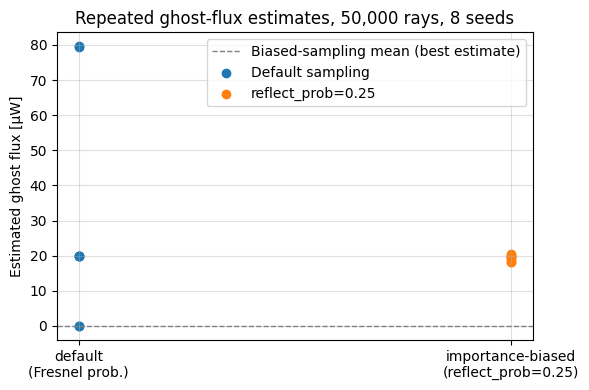

In [8]:
n_repeats = 8
budget = 50_000


def repeated_ghosts(reflect_prob):
    return np.array([
        ghost_flux(coated=True, reflect_prob=reflect_prob,
                  num_rays=budget, seed=s)[2]
        for s in range(n_repeats)
    ])


ghosts_default = repeated_ghosts('fresnel')
ghosts_biased = repeated_ghosts(0.25)

rel_std_default = 100 * ghosts_default.std() / ghosts_default.mean()
rel_std_biased = 100 * ghosts_biased.std() / ghosts_biased.mean()
variance_reduction = (ghosts_default.std() / ghosts_biased.std()) ** 2

print(f"{budget:,} rays x {n_repeats} repeats, AR-coated ghost flux estimate:")
print(f"  default sampling   : mean={ghosts_default.mean():.6f} W, "
      f"rel. std={rel_std_default:.0f}%")
print(f"  reflect_prob=0.25  : mean={ghosts_biased.mean():.6f} W, "
      f"rel. std={rel_std_biased:.1f}%")
print(f"  variance reduction : {variance_reduction:.0f}x, at zero extra ray cost")

fig, ax = plt.subplots(figsize=(6, 4))
ax.axhline(ghosts_biased.mean(), color='gray', lw=1, ls='--',
           label='Biased-sampling mean (best estimate)')
ax.scatter(np.zeros(n_repeats), ghosts_default * 1e6, label='Default sampling')
ax.scatter(np.ones(n_repeats), ghosts_biased * 1e6, label='reflect_prob=0.25')
ax.set_xticks([0, 1])
ax.set_xticklabels(['default\n(Fresnel prob.)', 'importance-biased\n(reflect_prob=0.25)'])
ax.set_ylabel('Estimated ghost flux [µW]')
ax.set_title(f'Repeated ghost-flux estimates, {budget:,} rays, {n_repeats} seeds')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
plt.close(fig)

## Summary

- `sequential_to_nonsequential(optic)` converts an `Optic` into an `NSQScene`
- The NSQ tracer applies **Fresnel splitting** at every uncoated interface, which
  is what produces ghosts; the sequential tracer transmits everything
- `max_depth` counts every interaction including the detector hit, so the direct
  path needs `surfaces + 1`. Anything beyond that admits ghost paths
- Tracing the same scene at two bounce limits and subtracting the irradiance maps
  isolates the stray-light pattern
- `min_flux_fraction` sets the Russian-roulette threshold that decides how far
  faint ghost rays are followed before being unbiasedly killed; lower it when
  chasing weak stray light
- `SurfaceConfig(coating=SimpleCoating(...))`, attached via `front=`/`back=` on a
  `LensConfig`, models a real AR coating instead of bare Fresnel — going from
  ~4% uncoated reflectance to a ~0.25% single-layer AR coat suppresses ghost
  flux by roughly an order of magnitude on the two-lens example above.
  **Ghost/stray-light numbers computed without coatings overstate what a real,
  coated lens would actually produce** — treat an uncoated analysis as a
  worst-case bound, not a prediction
- `scene.sampling_policy = SamplingPolicy(reflect_prob=...)` biases how often
  the tracer samples the reflect branch (with a compensating weight, so the
  expected result is unchanged) — essential for getting usable statistics on
  a faint, AR-coated ghost without a much larger ray budget
- Mirrors also carry a required, physically real `reflectance` now (see
  notebook 09), so a stray-light budget that includes mirrors is likewise more
  meaningful than a model that silently assumed 100% reflection
- `result.report()` flags undersampled detectors and Russian-roulette losses —
  worth checking whenever a faint stray-light signal is the thing you actually
  care about
